In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

In [2]:
# total max emitted power by laser
P_e_tot = 75e-3 * u.W # W

# numberical aperture NA
NA = 0.3

# wavelength
wavel_lambda = 3.91e-6 * u.m # m

In [3]:
# detector received power limit: 2 mW/mm2 (WinCamD-IR-BB)
P_area_detector_limit = (2e-3) * u.W / u.mm**2 # 2 mW/mm2

In [4]:
# eye limit at 4 um: 0.1 W/cm2; conservative but rough estimate
P_area_eye_limit = 1e-1 * u.W/u.cm**2 # W/m2

In [5]:
# horizontal linear displacement
d_horiz = np.arange(0, 2, 0.01) * u.m # m

In [6]:
# incident power per unit area 

def calc_incident_power(d_horiz, NA, P_e_tot):

    angle_divergence = np.arcsin(NA)

    rad_beam = d_horiz * np.tan( angle_divergence )
    P_area_incident = P_e_tot / (np.pi * np.power(rad_beam, 2) )

    return P_area_incident.to(u.mW/u.mm**2)

In [21]:
P_area_incident = calc_incident_power(d_horiz=d_horiz, NA=0.3, P_e_tot=183e-3 * u.W)

#print(test)

/Users/eckhartspalding/miniconda3/envs/nice/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [9]:
# beam radius 

#print('Beam radius (cm): ', rad_beam*100)
#plt.clf()
'''
plt.plot(d_horiz.to(u.cm), rad_beam.to(u.cm))
plt.xlabel('Horizontal Displacement (cm)')
plt.ylabel('Beam Radius (cm)')
plt.show()
'''


"\nplt.plot(d_horiz.to(u.cm), rad_beam.to(u.cm))\nplt.xlabel('Horizontal Displacement (cm)')\nplt.ylabel('Beam Radius (cm)')\nplt.show()\n"

In [22]:
# the amount by which the laser is stopped down by for OD5
P_area_incident_OD5 = P_area_incident * 1e-5

In [20]:
P_area_incident

<Quantity 0.00026264 mW / mm2>

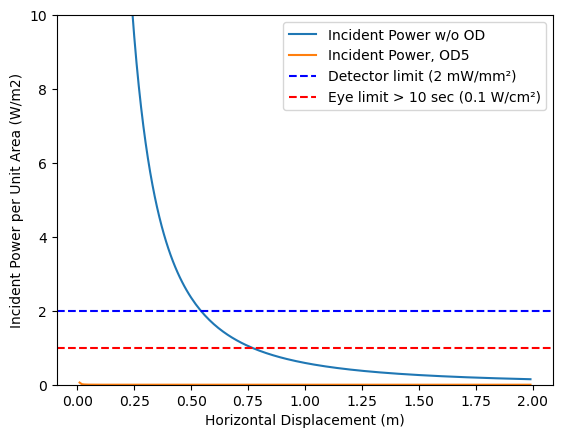

In [25]:
plt.plot(d_horiz.to(u.m), P_area_incident.to(u.W/u.m**2), label='Incident Power w/o OD')
plt.plot(d_horiz.to(u.m), P_area_incident_OD5.to(u.W/u.m**2), label='Incident Power, OD5')
# Convert limits to same units as P_area_incident (W/m²) for correct comparison
P_area_detector_limit_Wm2 = P_area_detector_limit.to(P_area_incident.unit)
P_area_eye_limit_Wm2 = P_area_eye_limit.to(P_area_incident.unit)
plt.axhline(y=P_area_detector_limit_Wm2.value, color='b', linestyle='--', label='Detector limit (2 mW/mm²)')
plt.axhline(y=P_area_eye_limit_Wm2.value, color='r', linestyle='--', label='Eye limit > 10 sec (0.1 W/cm²)')
plt.ylim(0, 10)
plt.legend()
plt.xlabel('Horizontal Displacement (m)')
plt.ylabel('Incident Power per Unit Area (W/m2)')
plt.show()

In [ ]:
# Gaussian beam propagation

wavel_lambda = 3.9 * u.um 
angle_divergence_test = np.arcsin(NA)
w_0_test = wavel_lambda / (np.pi * angle_divergence_test)
z_R = np.pi * w_0**2 / wavel_lambda

In [52]:
print(w_0)
print(z_R)
print(d_horiz)

4.074297623381658 um
13.371827543882189 um
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11
 1.12 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2  1.21 1.22 1.23 1.24 1.25
 1.26 1.27 1.28 1.29 1.3  1.31 1.32 1.33 1.34 1.35 1.36 1.37 1.38 1.39
 1.4  1.41 1.42 1.43 1.44 1.45 1.46 1.47 1.48 1.49 1.5  1.51 1.52 1.53
 1.54 1.55 1.56 1.57 1.58 1.59 1.6  1.61 1.62 1.63 1.64 1.65 1.66 1.67
 1.68 1.69 1.7  1.71 1.72 1.73 1.74 1.75 1.76 1.77 1.78 1.79 1.8  1.81
 1.82 1.83 1.84 1.85 1.86 1.87 1.8

In [30]:
angle_divergence * 180 / (np.pi)

np.float64(17.45760312372209)

In [84]:
def w_z(z, z_R, NA):
    '''
    Gaussian beam waist

    INPUTS:
    w0: float, beam waist
    z: float, distance between source and detector
    z_R: float, Rayleigh range
    NA: float, numerical aperture

    OUTPUTS:
    w_z: float, beam waist at z
    '''

    angle_divergence = np.arcsin(NA)
    w_0 = 2. * wavel_lambda / (np.pi * angle_divergence) # for TEM00 mode

    return w_0 * np.sqrt(1 + (z.to(u.m) / z_R.to(u.m))**2)

In [83]:
angle_divergence = np.arcsin(0.3)
print(angle_divergence)
w_0 = 2. * wavel_lambda / (np.pi * angle_divergence)
print(w_0)

0.30469265401539747
8.148595246763316 um


In [ ]:
# expansion of the beam

width_test = w_z(z=d_horiz, z_R=z_R, NA=0.3) 

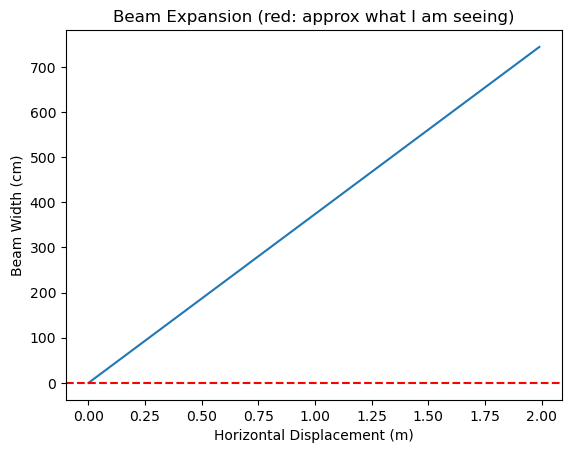

In [85]:
plt.plot(d_horiz.to(u.m), width_test.to(u.cm))
plt.axhline(y=0.5, linestyle='--', color='red')
plt.xlabel('Horizontal Displacement (m)')
plt.ylabel('Beam Width (cm)')
plt.title('Beam Expansion (red: approx what I am seeing)')
plt.show()


In [40]:
# make an array to simulate the detector

array_pixels = np.zeros((640, 480), dtype=int)

pix_scale = 5.5 * u.um # um per pixel side

# Create an array with values denoting distance from the center
center_x = array_pixels.shape[0] // 2
center_y = array_pixels.shape[1] // 2
x_indices, y_indices = np.indices(array_pixels.shape)
array_phys_dist = np.sqrt((x_indices - center_x)**2 + (y_indices - center_y)**2) * pix_scale.value

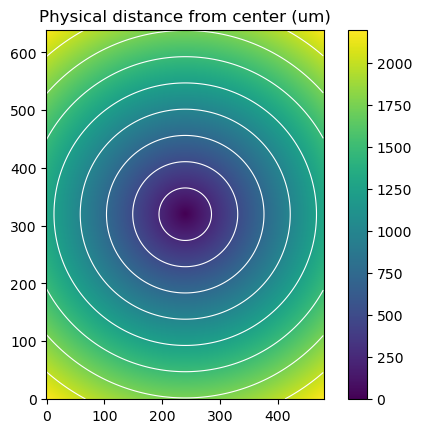

In [86]:
plt.imshow(array_phys_dist, origin='lower')
plt.title('Physical distance from center (um)')
# Add contours at steps of 250 um.
contour_levels = np.arange(0, np.max(array_phys_dist), 250)
plt.colorbar()
plt.contour(array_phys_dist, levels=contour_levels, colors='white', linewidths=0.8)
plt.show()

In [90]:
w_z(z=d_horiz, z_R=z_R, NA=0.3) 

<Quantity [8.14859525e+00, 6.09385853e+03, 1.21877089e+04, 1.82815611e+04,
           2.43754137e+04, 3.04692665e+04, 3.65631194e+04, 4.26569723e+04,
           4.87508253e+04, 5.48446783e+04, 6.09385313e+04, 6.70323844e+04,
           7.31262374e+04, 7.92200905e+04, 8.53139435e+04, 9.14077966e+04,
           9.75016496e+04, 1.03595503e+05, 1.09689356e+05, 1.15783209e+05,
           1.21877062e+05, 1.27970915e+05, 1.34064768e+05, 1.40158621e+05,
           1.46252474e+05, 1.52346327e+05, 1.58440180e+05, 1.64534033e+05,
           1.70627886e+05, 1.76721740e+05, 1.82815593e+05, 1.88909446e+05,
           1.95003299e+05, 2.01097152e+05, 2.07191005e+05, 2.13284858e+05,
           2.19378711e+05, 2.25472564e+05, 2.31566417e+05, 2.37660270e+05,
           2.43754123e+05, 2.49847976e+05, 2.55941830e+05, 2.62035683e+05,
           2.68129536e+05, 2.74223389e+05, 2.80317242e+05, 2.86411095e+05,
           2.92504948e+05, 2.98598801e+05, 3.04692654e+05, 3.10786507e+05,
           3.16880360e+05

In [ ]:
# plot normalized? intensity on the array

w_z(z=d_horiz, z_R=z_R, NA=0.3)

In [91]:
# intensity distribution


def I_r(r, w_0, z_R, NA):
    '''
    Intensity distribution of a Gaussian beam

    INPUTS:
    r: float, distance from center
    w_0: float, beam waist
    z_R: float, Rayleigh range
    NA: float, numerical aperture

    OUTPUTS:
    I_r: float, intensity at r
    '''

    w_z_this = w_z(z=r, z_R=z_R, NA=NA)

    return np.exp(-2 * r**2 / w_z_this**2)



In [92]:
d_horiz_this = 1.45 * u.m

test = I_r(r=array_phys_dist, w_0=w_0, z_R=z_R, NA=0.3)

AttributeError: 'numpy.ndarray' object has no attribute 'to'